<a href="https://colab.research.google.com/github/DimDragg/-/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_9%2C10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота № 9 – 10: Дослідження в сфері комп’ютерних наук на основі імітаційного моделювання.

Чуркін Дмитро, ФІТ 3-15

МЕТА: здійснити імітаційне моделювання комп’ютерної системи на основі дискретно-подієвого та агентного моделювання.

Був присутній на парі

Завдання: Розробити імітаційну модель комп’ютерної системи обробки запитів користувачів на основі дискретно-подієвого та агентного моделювання. В моделі реалізувати надходження кількох типів запитів і врахувати механізм розподілу типів запитів між серверами; інтенсивність надходження запитів залежить від часу доби. Вхідні дані взяти наближені до реалістичних. Моделювання здійснювати протягом більше 1000 одиниць часу. Здійснити всі етапи імітаційного моделювання. Визначити: середній час очікування заявки; середній час перебування в системі; середню довжину черги; коефіцієнти завантаження серверів; кількість оброблених заявок. Побудувати графіки відповідних показників СМО. Порівняти отримані результати на основі дискретно-подієвого і агентного моделювання за такими критеріями: точність, швидкість моделювання, складність реалізації, масштабованість.

In [2]:
!pip install simpy

DISCRETE EVENT
Середній час очікування: 0.37
Середній час у системі: 5.36
Середня довжина черги: 0.12
Кількість оброблених: 184

AGENT MODEL
Середній час очікування: 443.61
Середня довжина черги: 1965.14
Кількість оброблених: 606


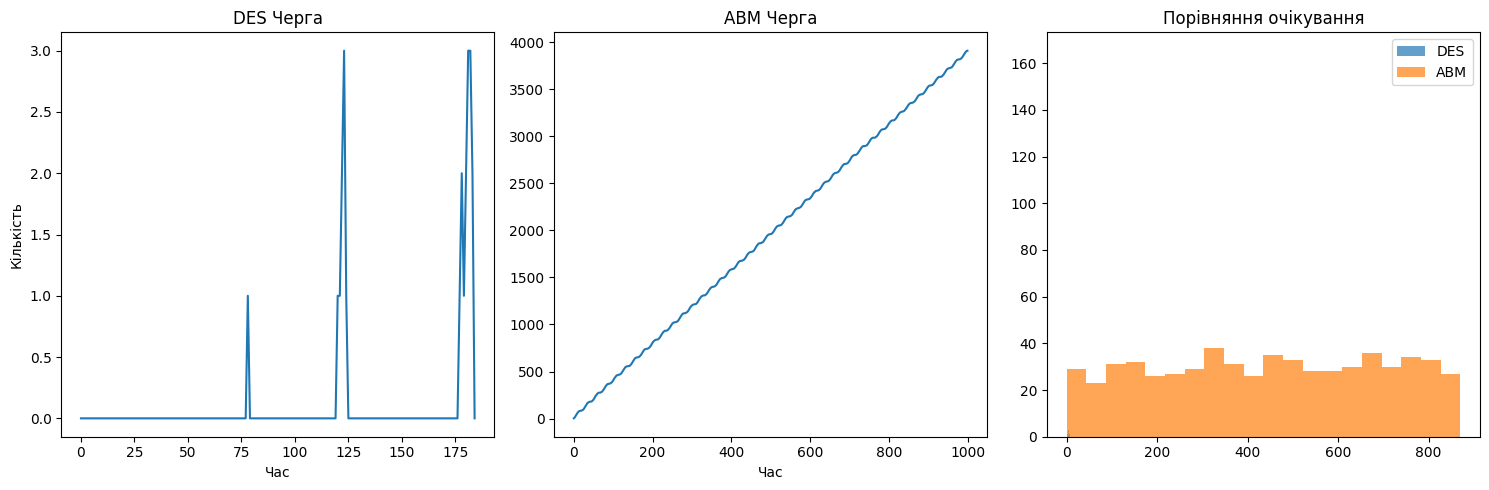

            Метод  Сер. очікування   Сер. черга  Оброблено
0  Discrete Event         0.372076     0.124324        184
1     Agent Based       443.608911  1965.138000        606


In [3]:
import simpy
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ПАРАМЕТРИ МОДЕЛЮВАННЯ
SIM_TIME = 1000
NUM_SERVERS = 3

# ФУНКЦІЯ ІНТЕНСИВНОСТІ ПОТОКУ
def arrival_rate(t):
    return 15 + 10*np.sin(2*np.pi*t/24)

# ЧАС ОБРОБКИ РІЗНИХ ТИПІВ
def service_time(req_type):
    if req_type == 1:
        return random.uniform(1,3)
    elif req_type == 2:
        return random.uniform(4,6)
    else:
        return random.uniform(7,10)

# DISCRETE EVENT MODEL (SIMPY)
wait_times = []
system_times = []
queue_lengths = []
processed_des = 0

def request_process(env, name, server):
    global processed_des

    arrival = env.now

    with server.request() as req:
        yield req

        wait = env.now - arrival
        wait_times.append(wait)

        req_type = random.choice([1,2,3])

        yield env.timeout(service_time(req_type))

        system_times.append(env.now-arrival)

        processed_des += 1

def generator(env, server):
    i = 0

    while True:
        lam = arrival_rate(env.now)

        yield env.timeout(random.expovariate(lam/60))

        env.process(request_process(env,f"Req{i}",server))

        queue_lengths.append(len(server.queue))

        i += 1

env = simpy.Environment()
server = simpy.Resource(env, capacity=NUM_SERVERS)

env.process(generator(env, server))
env.run(until=SIM_TIME)

# AGENT MODEL
servers = [0]*NUM_SERVERS
queue = []

processed_agent = 0
agent_waits = []
agent_queue_lengths = []

for t in range(SIM_TIME):

    arrivals = int(arrival_rate(t)/3)

    for _ in range(arrivals):
        queue.append({
            "type": random.choice([1,2,3]),
            "arrival": t
        })

    for i in range(NUM_SERVERS):

        if servers[i] <= 0 and queue:

            req = queue.pop(0)

            agent_waits.append(t-req["arrival"])

            if req["type"] == 1:
                servers[i] = 2
            elif req["type"] == 2:
                servers[i] = 5
            else:
                servers[i] = 8

            processed_agent += 1

        servers[i] -= 1

    agent_queue_lengths.append(len(queue))

# РЕЗУЛЬТАТИ
print("DISCRETE EVENT")
print("Середній час очікування:", round(np.mean(wait_times),2))
print("Середній час у системі:", round(np.mean(system_times),2))
print("Середня довжина черги:", round(np.mean(queue_lengths),2))
print("Кількість оброблених:", processed_des)

print()

print("AGENT MODEL")
print("Середній час очікування:", round(np.mean(agent_waits),2))
print("Середня довжина черги:", round(np.mean(agent_queue_lengths),2))
print("Кількість оброблених:", processed_agent)

# ГРАФІКИ
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.plot(queue_lengths)
plt.title("DES Черга")
plt.xlabel("Час")
plt.ylabel("Кількість")

plt.subplot(1,3,2)
plt.plot(agent_queue_lengths)
plt.title("ABM Черга")
plt.xlabel("Час")

plt.subplot(1,3,3)
plt.hist(wait_times,bins=20,alpha=0.7,label="DES")
plt.hist(agent_waits,bins=20,alpha=0.7,label="ABM")
plt.legend()
plt.title("Порівняння очікування")

plt.tight_layout()
plt.show()

# ПОРІВНЯЛЬНА ТАБЛИЦЯ
results = pd.DataFrame({
    "Метод":["Discrete Event","Agent Based"],
    "Сер. очікування":[np.mean(wait_times),np.mean(agent_waits)],
    "Сер. черга":[np.mean(queue_lengths),np.mean(agent_queue_lengths)],
    "Оброблено":[processed_des,processed_agent]
})

print(results)